<a href="https://colab.research.google.com/github/GabrielHinostroza2/Fraude_Tarjeta_Credito/blob/main/Fraude_Tarjeta_Credito_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°1 — DLY0100 Deep Learning
## Detección de Fraude en Tarjetas de Crédito con MLP

**Asignatura:** Fundamentos de Deep Learning  
**Dataset:** Credit Card Fraud Detection (Kaggle)  
**Framework:** TensorFlow / Keras  

---

## 1. Introducción

### Descripción del Problema

El fraude en tarjetas de crédito representa pérdidas millonarias para la industria financiera.
Este proyecto implementa una **Red Neuronal Artificial Multicapa (MLP)** para clasificar
transacciones como legítimas o fraudulentas.

### Características del Dataset

| Atributo | Valor |
|---|---|
| Total de transacciones | 284,807 |
| Transacciones fraudulentas | 492 (0.17%) |
| Features | 30 (V1–V28 con PCA + Time + Amount) |
| Variable objetivo | `Class` (0 = legítima, 1 = fraude) |

### Desafíos Principales

1. **Desbalance extremo**: 99.83% legítimas vs 0.17% fraudes. Un modelo que prediga siempre 0 tendría 99.83% de accuracy pero sería inútil.
2. **Costo asimétrico del error**: un fraude no detectado (FN) es mucho más costoso que una falsa alarma (FP).
3. **Alta dimensionalidad**: 30 features requieren regularización para evitar overfitting.

### Objetivo

Entrenar un MLP que maximice el **Recall** en la clase fraude, evaluado con accuracy, precision, recall y F1-score.

## 2. Instalación y Configuración del Entorno

In [ ]:
# Instalación de librerías
!pip install -q tensorflow scikit-learn imbalanced-learn matplotlib seaborn pandas numpy

# Importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'legit': '#2196F3', 'fraud': '#F44336', 'val': '#FF9800'}

print(f"TensorFlow: {tf.__version__}")
print("Entorno configurado correctamente")

TensorFlow: 2.20.0
Entorno configurado correctamente


## 3. Carga y Exploración de Datos

### 3.1 Carga del Dataset

Las features V1–V28 ya están transformadas con PCA, por lo que **solo escalaremos `Time` y `Amount`**.

> Cargar datos del CSV

In [ ]:

DATA_PATH = 'creditcard.csv'   # <-- ajusta si es necesario

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Análisis exploratorio básico
print("=" * 50)
print("INFORMACIÓN GENERAL")
print("=" * 50)
print(f"  Filas         : {df.shape[0]:,}")
print(f"  Columnas      : {df.shape[1]}")
print(f"  Valores nulos : {df.isnull().sum().sum()}")
print(f"  Duplicados    : {df.duplicated().sum()}")

class_counts = df['Class'].value_counts()
print()
print("DISTRIBUCIÓN DE CLASES")
print("-" * 40)
for cls, count in class_counts.items():
    label = 'Legítima' if cls == 0 else 'Fraude  '
    pct = count / len(df) * 100
    print(f"  Clase {cls} ({label}): {count:>7,}  ({pct:.3f}%)")
print(f"\n  Ratio de desbalance: {class_counts[0]/class_counts[1]:.0f}:1")

INFORMACIÓN GENERAL
  Filas         : 284,807
  Columnas      : 31
  Valores nulos : 0
  Duplicados    : 1081

DISTRIBUCIÓN DE CLASES
----------------------------------------
  Clase 0 (Legítima): 284,315  (99.827%)
  Clase 1 (Fraude  ):     492  (0.173%)

  Ratio de desbalance: 578:1


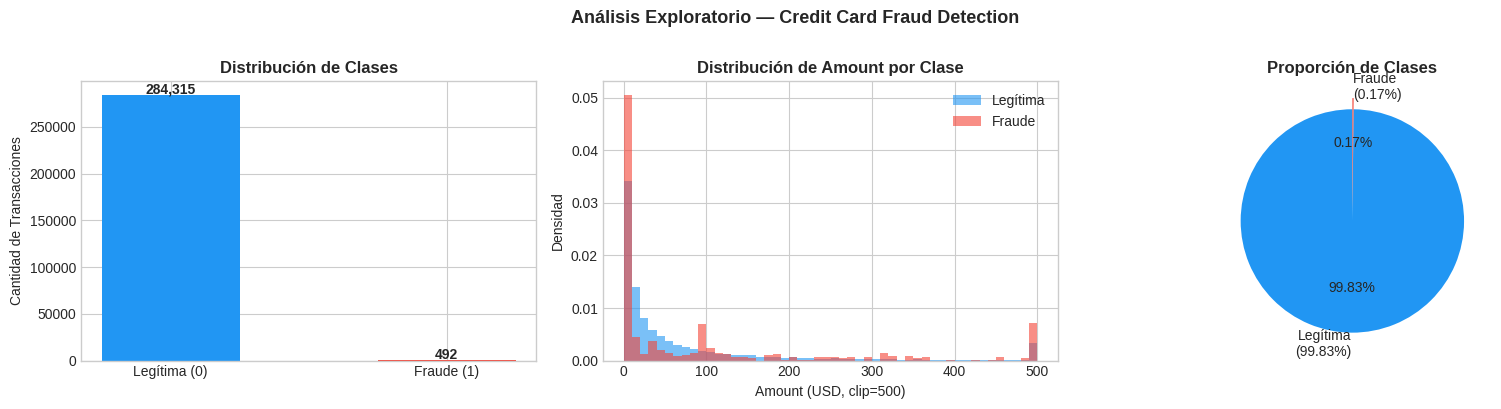

In [ ]:
# Visualización del desbalance y distribución de Amount
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Barras de clases
axes[0].bar(['Legítima (0)', 'Fraude (1)'],
            class_counts.values,
            color=[COLORS['legit'], COLORS['fraud']], width=0.5)
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Cantidad de Transacciones')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 800, f'{v:,}', ha='center', fontweight='bold')

# Histograma Amount por clase
for cls, color, label in [(0, COLORS['legit'], 'Legítima'),
                           (1, COLORS['fraud'], 'Fraude')]:
    axes[1].hist(df[df['Class'] == cls]['Amount'].clip(upper=500),
                 bins=50, alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('Distribución de Amount por Clase', fontweight='bold')
axes[1].set_xlabel('Amount (USD, clip=500)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

# Pie chart
axes[2].pie(class_counts.values,
            labels=['Legítima\n(99.83%)', 'Fraude\n(0.17%)'],
            colors=[COLORS['legit'], COLORS['fraud']],
            explode=(0, 0.1), autopct='%1.2f%%', startangle=90)
axes[2].set_title('Proporción de Clases', fontweight='bold')

plt.suptitle('Análisis Exploratorio — Credit Card Fraud Detection',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocesamiento de Datos

### Decisiones de Preprocesamiento

| Feature | Tratamiento | Justificación |
|---|---|---|
| V1–V28 | **Sin escalar** | Ya transformadas con PCA por el proveedor |
| `Time` | **StandardScaler ajustado SOLO con train** | Valores absolutos en segundos; escalar mejora convergencia y evita data leakage |
| `Amount` | **StandardScaler ajustado SOLO con train** | Rango muy amplio; escalar es esencial y se debe ajustar solo con datos de entrenamiento |
| Duplicados | **Eliminados** | Evitar sesgo en el entrenamiento |
| Desbalance | **SMOTE solo en train** | Genera muestras sintéticas de la clase minoritaria sin contaminar validación/test |

> **Importante:** primero se divide el dataset y después se ajusta el `StandardScaler` únicamente con `X_train`. Luego se transforman `X_train`, `X_val` y `X_test`. Esto evita **data leakage**, porque validación y test no influyen en el preprocesamiento.


In [ ]:
# 4.1 Eliminar duplicados
n_before = len(df)
df = df.drop_duplicates()
print(f"Filas eliminadas (duplicados): {n_before - len(df)}")

# Eliminar filas con NaN en la columna 'Class'
n_before_nan = len(df)
df.dropna(subset=['Class'], inplace=True)
print(f"Filas eliminadas (NaN en Class): {n_before_nan - len(df)}")

# 4.2 Separar features y target
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

# 4.3 Split estratificado 70 / 15 / 15
# Se divide ANTES de escalar para evitar data leakage.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp)

# 4.4 Escalar Time y Amount únicamente
# El scaler se ajusta SOLO con train y luego se aplica a val/test.
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val[['Time', 'Amount']]   = scaler.transform(X_val[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

print("\nEstadísticas de Time y Amount después del escalado en TRAIN:")
print(X_train[['Time', 'Amount']].describe().round(3))

print("\nTamaño de los conjuntos:")
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pct = ys.sum() / len(ys) * 100
    print(f"  {name:5s}: {len(ys):>7,} muestras | fraudes: {ys.sum():>4} ({pct:.2f}%)")

Filas eliminadas (duplicados): 1081
Filas eliminadas (NaN en Class): 0

Estadísticas de Time y Amount después del escalado en TRAIN:
             Time      Amount
count  198721.000  198721.000
mean       -0.000      -0.000
std         1.000       1.000
min        -1.998      -0.364
25%        -0.857      -0.341
50%        -0.214      -0.273
75%         0.936      -0.043
max         1.642      80.740

Tamaño de los conjuntos:
  Train: 198,721 muestras | fraudes:  331 (0.17%)
  Val  :  42,446 muestras | fraudes:   71 (0.17%)
  Test :  42,559 muestras | fraudes:   71 (0.17%)


In [ ]:
# 4.5 SMOTE: oversampling solo en entrenamiento
smote = SMOTE(sampling_strategy=0.1, random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Resultado de SMOTE:")
print(f"  Antes : {len(y_train):>7,} | fraudes: {y_train.sum()}")
print(f"  Después: {len(y_train_res):>7,} | fraudes: {y_train_res.sum()}")
print(f"  Nuevo ratio fraude: {y_train_res.sum()/len(y_train_res)*100:.2f}%")

# Convertir a numpy float32 para TensorFlow
X_train_np = X_train_res.values.astype('float32')
y_train_np = y_train_res.values.astype('float32')
X_val_np   = X_val.values.astype('float32')
y_val_np   = y_val.values.astype('float32')
X_test_np  = X_test.values.astype('float32')
y_test_np  = y_test.values.astype('float32')

print(f"\nInput shape: {X_train_np.shape[1]} features")
print("Datos listos para el modelo")

Resultado de SMOTE:
  Antes : 198,721 | fraudes: 331
  Después: 218,229 | fraudes: 19839
  Nuevo ratio fraude: 9.09%

Input shape: 30 features
Datos listos para el modelo


## 5. Definición del Modelo MLP

### Arquitectura Base

```
Input (30)  →  Dense(128, ReLU)  →  BatchNorm  →  Dropout(0.4)
            →  Dense(64,  ReLU)  →  BatchNorm  →  Dropout(0.3)
            →  Dense(32,  ReLU)  →  BatchNorm  →  Dropout(0.2)
            →  Dense(1,   Sigmoid)
```

### Justificación de Funciones

| Componente | Elección | Justificación |
|---|---|---|
| Activación ocultas | **ReLU** | Evita vanishing gradient; convergencia rápida |
| Activación salida | **Sigmoid** | Mapea a [0,1] → probabilidad de fraude |
| Función de error base | **Binary Cross-Entropy** | Estándar para clasificación binaria |
| Función de error alternativa | **Focal Loss / BCE con label smoothing** | Útiles para analizar el efecto de la función de pérdida en un problema desbalanceado |
| Regularización | **Dropout + L2 + BatchNorm** | Previene overfitting y estabiliza el entrenamiento |
| Optimizador base | **Adam** | Adaptativo, eficiente y robusto |


In [ ]:

def focal_loss(alpha=0.25, gamma=2.0):
    """
    Focal Loss para clasificación binaria.

    Reduce el peso de ejemplos fáciles y enfoca el entrenamiento en ejemplos difíciles.
    Es útil en datasets muy desbalanceados, como detección de fraude.
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, keras.backend.epsilon(), 1 - keras.backend.epsilon())
        bce = keras.backend.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(alpha_factor * modulating_factor * bce)
    return loss


def build_mlp(input_dim=30,
              units=[128, 64, 32],
              activation='relu',
              dropout_rates=[0.4, 0.3, 0.2],
              use_bn=True,
              l2_reg=0.001,
              learning_rate=0.001,
              optimizer_name='adam',
              loss_fn='binary_crossentropy'):
    """

    Parámetros
    ----------
    input_dim      : número de features de entrada
    units          : neuronas por capa oculta
    activation     : función de activación de capas ocultas
    dropout_rates  : tasa de dropout por capa
    use_bn         : activar Batch Normalization
    l2_reg         : coeficiente de regularización L2
    learning_rate  : tasa de aprendizaje inicial
    optimizer_name : 'adam', 'sgd' o 'rmsprop'
    loss_fn        : función de error/pérdida a optimizar
    """
    model = keras.Sequential(name='MLP_FraudeDetector')
    model.add(keras.Input(shape=(input_dim,)))

    for i, (n, dr) in enumerate(zip(units, dropout_rates)):
        model.add(layers.Dense(n, activation=activation,
                               kernel_regularizer=regularizers.l2(l2_reg),
                               name=f'hidden_{i+1}'))
        if use_bn:
            model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Dropout(dr, name=f'dropout_{i+1}'))

    model.add(layers.Dense(1, activation='sigmoid', name='output'))

    opts = {
        'adam':    keras.optimizers.Adam(learning_rate=learning_rate),
        'sgd':     keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9),
        'rmsprop': keras.optimizers.RMSprop(learning_rate=learning_rate)
    }

    model.compile(
        optimizer=opts[optimizer_name],
        loss=loss_fn,
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(name='auc')]
    )
    return model

# Construir y mostrar el modelo base
model_base = build_mlp(input_dim=X_train_np.shape[1])
model_base.summary()


Model: "MLP_FraudeDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

## 6. Entrenamiento del Modelo Base

### Configuración de Hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| **Épocas** | 50 (EarlyStopping) | EarlyStopping detiene si val_loss no mejora |
| **Batch Size** | 512 | Balance entre velocidad y varianza del gradiente |
| **Learning Rate** | 0.001 | Valor estándar para Adam |
| **Optimizador** | Adam | Adaptativo y robusto |
| **class_weight** | {0:1, 1:10} | Penaliza 10× más los fraudes no detectados |

In [ ]:
THRESHOLDS = np.arange(0.1, 0.9, 0.05)
CLASS_WEIGHT = {0: 1.0, 1: 10.0}

callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

print("Entrenando modelo base...")
history_base = model_base.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=50,
    batch_size=512,
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks_base,
    verbose=1
)

Entrenando modelo base...
Epoch 1/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9372 - auc: 0.9876 - loss: 0.4363 - precision: 0.5978 - recall: 0.9447 - val_accuracy: 0.9871 - val_auc: 0.9742 - val_loss: 0.1862 - val_precision: 0.1047 - val_recall: 0.8873 - learning_rate: 0.0010
Epoch 2/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9831 - auc: 0.9984 - loss: 0.2048 - precision: 0.8525 - recall: 0.9845 - val_accuracy: 0.9943 - val_auc: 0.9780 - val_loss: 0.1219 - val_precision: 0.2089 - val_recall: 0.8592 - learning_rate: 0.0010
Epoch 3/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9894 - auc: 0.9991 - loss: 0.1401 - precision: 0.9014 - recall: 0.9916 - val_accuracy: 0.9958 - val_auc: 0.9611 - val_loss: 0.0914 - val_precision: 0.2672 - val_recall: 0.8732 - learning_rate: 0.0010
Epoch 4/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9925 - auc: 0.9993 - loss: 0.1024 - precision: 0.9279 - recall: 0.9946 - val_accuracy: 0.9968 - val_auc: 0.

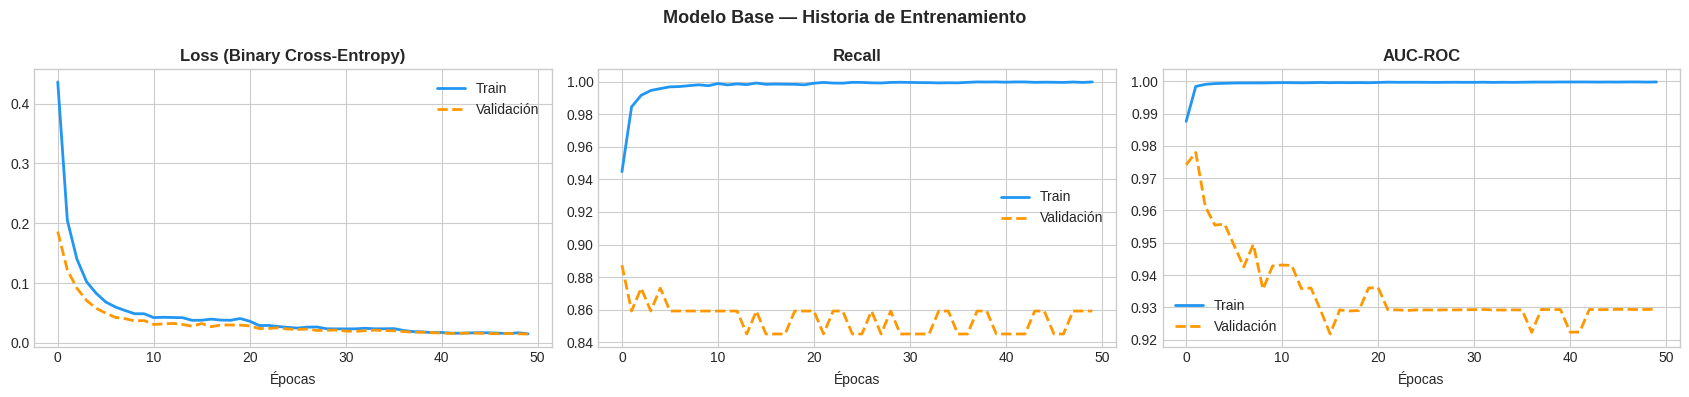

In [ ]:
def plot_training_history(history, title='Entrenamiento'):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    for ax, (metric, label) in zip(axes, [
            ('loss',   'Loss (Binary Cross-Entropy)'),
            ('recall', 'Recall'),
            ('auc',    'AUC-ROC')]):
        ax.plot(history.history[metric],
                label='Train', color=COLORS['legit'], lw=2)
        ax.plot(history.history[f'val_{metric}'],
                label='Validación', color=COLORS['val'], lw=2, linestyle='--')
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Épocas')
        ax.legend()
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_base, 'Modelo Base — Historia de Entrenamiento')

## 7. Evaluación del Modelo — Métricas

### Significado de las Métricas en Detección de Fraude

| Métrica | Fórmula | Relevancia en Fraude |
|---|---|---|
| **Accuracy** | (TP+TN)/(Total) | Poco útil con clases desbalanceadas |
| **Precision** | TP/(TP+FP) | % de alertas que son fraudes reales (costo FP: cliente molesto) |
| **Recall** | TP/(TP+FN) | % de fraudes detectados ← **métrica prioritaria** |
| **F1-Score** | 2·(P·R)/(P+R) | Balance entre precision y recall |
| **AUC-ROC** | Área bajo curva ROC | Capacidad discriminativa global |

Threshold óptimo (max F1 en validación): 0.80

  EVALUACIÓN: Modelo Base
  Accuracy    : 0.9994
  Precision   : 0.8235
  Recall      : 0.7887
  F1-Score    : 0.8058
  AUC-ROC     : 0.9133

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     42488
      Fraude       0.82      0.79      0.81        71

    accuracy                           1.00     42559
   macro avg       0.91      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559



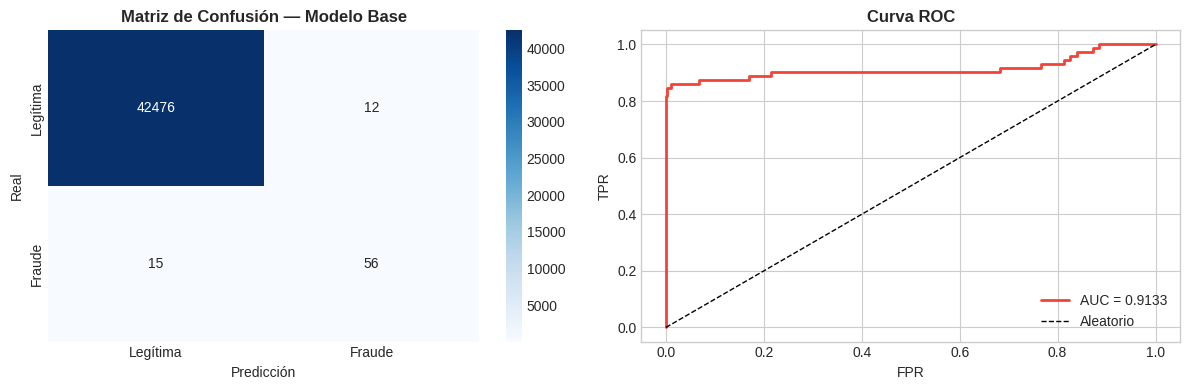

In [ ]:
def evaluate_model(model, X_test, y_test, threshold=0.5, model_name='Modelo'):
    """Evalúa completamente un modelo de clasificación binaria."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'Modelo'   : model_name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
        'Threshold': threshold
    }

    print(f"\n{'='*55}")
    print(f"  EVALUACIÓN: {model_name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        if k not in ['Modelo', 'Threshold']:
            print(f"  {k:<12}: {v:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legítima','Fraude'])}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Legítima','Fraude'],
                yticklabels=['Legítima','Fraude'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}', fontweight='bold')
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=COLORS['fraud'], lw=2,
                 label=f"AUC = {metrics['AUC-ROC']:.4f}")
    axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Aleatorio')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"eval_{model_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return metrics

# Encontrar threshold óptimo sobre validación (maximiza F1)
y_val_prob = model_base.predict(X_val_np, verbose=0).flatten()
f1_vals = [f1_score(y_val_np, (y_val_prob >= t).astype(int), zero_division=0)
           for t in THRESHOLDS]
best_threshold = THRESHOLDS[np.argmax(f1_vals)]
print(f"Threshold óptimo (max F1 en validación): {best_threshold:.2f}")

metrics_base = evaluate_model(model_base, X_test_np, y_test_np,
                              threshold=best_threshold,
                              model_name='Modelo Base')

## 8. Experimentos Controlados — Análisis de Hiperparámetros

Se varía **un parámetro a la vez**, manteniendo los demás fijos en sus valores base. Esto responde directamente a la rúbrica, que solicita experimentos controlados y comparación mediante tablas/gráficos.

| Experimento | Variable | Valores | Resto fijo |
|---|---|---|---|
| A | Batch Size | 128, 256, 512, 1024 | LR=0.001, Adam, BCE |
| B | Learning Rate | 0.0001, 0.001, 0.01, 0.1 | BS=512, Adam, BCE |
| C | Optimizador | Adam, SGD, RMSprop | BS=512, **LR=0.001**, BCE |
| D | Función de Activación | ReLU, ELU, Tanh | BS=512, LR=0.001, Adam, BCE |
| E | Función de Error/Pérdida | BCE, BCE con label smoothing, Focal Loss | BS=512, LR=0.001, Adam, ReLU |


In [ ]:
def quick_eval(model, name):
    """Retorna métricas en test usando el threshold que maximiza F1 en validación."""
    vp = model.predict(X_val_np, verbose=0).flatten()
    f1_by_threshold = [
        f1_score(y_val_np, (vp >= t).astype(int), zero_division=0)
        for t in THRESHOLDS
    ]
    thr = THRESHOLDS[np.argmax(f1_by_threshold)]

    yp = model.predict(X_test_np, verbose=0).flatten()
    yc = (yp >= thr).astype(int)
    return {
        'Modelo'    : name,
        'Precision' : round(precision_score(y_test_np, yc, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test_np, yc, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test_np, yc, zero_division=0), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test_np, yp), 4),
        'Threshold' : round(float(thr), 2)
    }

CB = [EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)]

# ═══ EXPERIMENTO A — Batch Size ══════════════════════════════════════════════
print("EXPERIMENTO A: Batch Size")
print("-" * 45)
results_A = []
for bs in [128, 256, 512, 1024]:
    m = build_mlp(input_dim=X_train_np.shape[1])
    m.fit(X_train_np, y_train_np,
          validation_data=(X_val_np, y_val_np),
          epochs=30, batch_size=bs, class_weight=CLASS_WEIGHT,
          callbacks=CB, verbose=0)
    row = quick_eval(m, str(bs))
    row['Batch Size'] = bs
    results_A.append(row)
    print(f"  BS={bs:4d}: F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | AUC={row['AUC-ROC']:.4f} | Thr={row['Threshold']:.2f}")

df_A = pd.DataFrame(results_A)[['Batch Size','Precision','Recall','F1-Score','AUC-ROC','Threshold']]
print("\nTabla Experimento A:")
display(df_A)


EXPERIMENTO A: Batch Size
---------------------------------------------
  BS= 128: F1=0.7250 | Recall=0.8169 | AUC=0.9186 | Thr=0.85
  BS= 256: F1=0.5634 | Recall=0.8451 | AUC=0.9522 | Thr=0.85
  BS= 512: F1=0.4762 | Recall=0.8451 | AUC=0.9612 | Thr=0.85
  BS=1024: F1=0.6073 | Recall=0.8169 | AUC=0.9451 | Thr=0.85

Tabla Experimento A:


,Batch Size,Precision,Recall,F1-Score,AUC-ROC,Threshold
0,128,0.6517,0.8169,0.7250,0.9186,0.85
1,256,0.4225,0.8451,0.5634,0.9522,0.85
2,512,0.3315,0.8451,0.4762,0.9612,0.85
3,1024,0.4833,0.8169,0.6073,0.9451,0.85


In [ ]:
# ═══ EXPERIMENTO B — Learning Rate ═══════════════════════════════════════════
print("EXPERIMENTO B: Learning Rate")
print("-" * 45)
results_B = []
for lr in [0.0001, 0.001, 0.01, 0.1]:
    m = build_mlp(input_dim=X_train_np.shape[1], learning_rate=lr)
    m.fit(X_train_np, y_train_np,
          validation_data=(X_val_np, y_val_np),
          epochs=30, batch_size=512, class_weight=CLASS_WEIGHT,
          callbacks=CB, verbose=0)
    row = quick_eval(m, str(lr))
    row['Learning Rate'] = lr
    results_B.append(row)
    print(f"  LR={lr}: F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | AUC={row['AUC-ROC']:.4f} | Thr={row['Threshold']:.2f}")

df_B = pd.DataFrame(results_B)[['Learning Rate','Precision','Recall','F1-Score','AUC-ROC','Threshold']]
print("\nTabla Experimento B:")
display(df_B)


EXPERIMENTO B: Learning Rate
---------------------------------------------
  LR=0.0001: F1=0.1953 | Recall=0.8169 | AUC=0.9581 | Thr=0.85
  LR=0.001: F1=0.4521 | Recall=0.8310 | AUC=0.9506 | Thr=0.85
  LR=0.01: F1=0.7170 | Recall=0.8028 | AUC=0.9413 | Thr=0.85
  LR=0.1: F1=0.7467 | Recall=0.7887 | AUC=0.9521 | Thr=0.85

Tabla Experimento B:


,Learning Rate,Precision,Recall,F1-Score,AUC-ROC,Threshold
0,0.0001,0.1109,0.8169,0.1953,0.9581,0.85
1,0.0010,0.3105,0.8310,0.4521,0.9506,0.85
2,0.0100,0.6477,0.8028,0.7170,0.9413,0.85
3,0.1000,0.7089,0.7887,0.7467,0.9521,0.85


In [ ]:
# ═══ EXPERIMENTO C — Optimizador ═════════════════════════════════════════════
print("EXPERIMENTO C: Optimizador")
print("-" * 45)
results_C = []

# Experimento controlado: se mantiene el mismo learning rate para todos.
FIXED_LR_OPTIMIZERS = 0.001

for opt_name in ['adam', 'sgd', 'rmsprop']:
    m = build_mlp(input_dim=X_train_np.shape[1],
                  optimizer_name=opt_name,
                  learning_rate=FIXED_LR_OPTIMIZERS)
    m.fit(X_train_np, y_train_np,
          validation_data=(X_val_np, y_val_np),
          epochs=40, batch_size=512, class_weight=CLASS_WEIGHT,
          callbacks=CB, verbose=0)
    row = quick_eval(m, opt_name.upper())
    row['Optimizador'] = opt_name.upper()
    row['Learning Rate'] = FIXED_LR_OPTIMIZERS
    results_C.append(row)
    print(f"  {opt_name.upper()}: F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | AUC={row['AUC-ROC']:.4f} | Thr={row['Threshold']:.2f}")

df_C = pd.DataFrame(results_C)[['Optimizador','Learning Rate','Precision','Recall','F1-Score','AUC-ROC','Threshold']]
print("\nTabla Experimento C:")
display(df_C)


EXPERIMENTO C: Optimizador
---------------------------------------------
  ADAM: F1=0.5310 | Recall=0.8451 | AUC=0.9652 | Thr=0.85
  SGD: F1=0.3440 | Recall=0.8310 | AUC=0.9731 | Thr=0.85
  RMSPROP: F1=0.7037 | Recall=0.8028 | AUC=0.9561 | Thr=0.85

Tabla Experimento C:


,Optimizador,Learning Rate,Precision,Recall,F1-Score,AUC-ROC,Threshold
0,ADAM,0.001,0.3871,0.8451,0.5310,0.9652,0.85
1,SGD,0.001,0.2169,0.8310,0.3440,0.9731,0.85
2,RMSPROP,0.001,0.6264,0.8028,0.7037,0.9561,0.85


In [ ]:
# ═══ EXPERIMENTO D — Función de Activación ═══════════════════════════════════
print("EXPERIMENTO D: Función de Activación")
print("-" * 45)
results_D = []
for act in ['relu', 'elu', 'tanh']:
    m = build_mlp(input_dim=X_train_np.shape[1], activation=act)
    m.fit(X_train_np, y_train_np,
          validation_data=(X_val_np, y_val_np),
          epochs=30, batch_size=512, class_weight=CLASS_WEIGHT,
          callbacks=CB, verbose=0)
    row = quick_eval(m, act.upper())
    row['Activación'] = act.upper()
    results_D.append(row)
    print(f"  {act.upper()}: F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | AUC={row['AUC-ROC']:.4f} | Thr={row['Threshold']:.2f}")

df_D = pd.DataFrame(results_D)[['Activación','Precision','Recall','F1-Score','AUC-ROC','Threshold']]
print("\nTabla Experimento D:")
display(df_D)


EXPERIMENTO D: Función de Activación
---------------------------------------------
  RELU: F1=0.5813 | Recall=0.8310 | AUC=0.9467 | Thr=0.85
  ELU: F1=0.2765 | Recall=0.8451 | AUC=0.9527 | Thr=0.85
  TANH: F1=0.3191 | Recall=0.8451 | AUC=0.9672 | Thr=0.85

Tabla Experimento D:


,Activación,Precision,Recall,F1-Score,AUC-ROC,Threshold
0,RELU,0.4470,0.8310,0.5813,0.9467,0.85
1,ELU,0.1653,0.8451,0.2765,0.9527,0.85
2,TANH,0.1967,0.8451,0.3191,0.9672,0.85


In [ ]:
# ═══ EXPERIMENTO E — Función de Error / Pérdida ═════════════════════════════
print("EXPERIMENTO E: Función de Error / Pérdida")
print("-" * 45)

loss_experiments = [
    ('Binary Cross-Entropy', 'binary_crossentropy'),
    ('BCE + label smoothing', keras.losses.BinaryCrossentropy(label_smoothing=0.01)),
    ('Focal Loss', focal_loss(alpha=0.25, gamma=2.0))
]

results_E = []
for loss_name, loss_fn in loss_experiments:
    m = build_mlp(input_dim=X_train_np.shape[1], loss_fn=loss_fn)
    m.fit(X_train_np, y_train_np,
          validation_data=(X_val_np, y_val_np),
          epochs=30, batch_size=512, class_weight=CLASS_WEIGHT,
          callbacks=CB, verbose=0)
    row = quick_eval(m, loss_name)
    row['Función de Error'] = loss_name
    results_E.append(row)
    print(f"  {loss_name}: F1={row['F1-Score']:.4f} | Recall={row['Recall']:.4f} | AUC={row['AUC-ROC']:.4f} | Thr={row['Threshold']:.2f}")

df_E = pd.DataFrame(results_E)[['Función de Error','Precision','Recall','F1-Score','AUC-ROC','Threshold']]
print("\nTabla Experimento E:")
display(df_E)


EXPERIMENTO E: Función de Error / Pérdida
---------------------------------------------
  Binary Cross-Entropy: F1=0.4396 | Recall=0.8451 | AUC=0.9559 | Thr=0.85
  BCE + label smoothing: F1=0.4715 | Recall=0.8169 | AUC=0.9614 | Thr=0.85
  Focal Loss: F1=0.8201 | Recall=0.8028 | AUC=0.9204 | Thr=0.60

Tabla Experimento E:


,Función de Error,Precision,Recall,F1-Score,AUC-ROC,Threshold
0,Binary Cross-Entropy,0.2970,0.8451,0.4396,0.9559,0.85
1,BCE + label smoothing,0.3314,0.8169,0.4715,0.9614,0.85
2,Focal Loss,0.8382,0.8028,0.8201,0.9204,0.60


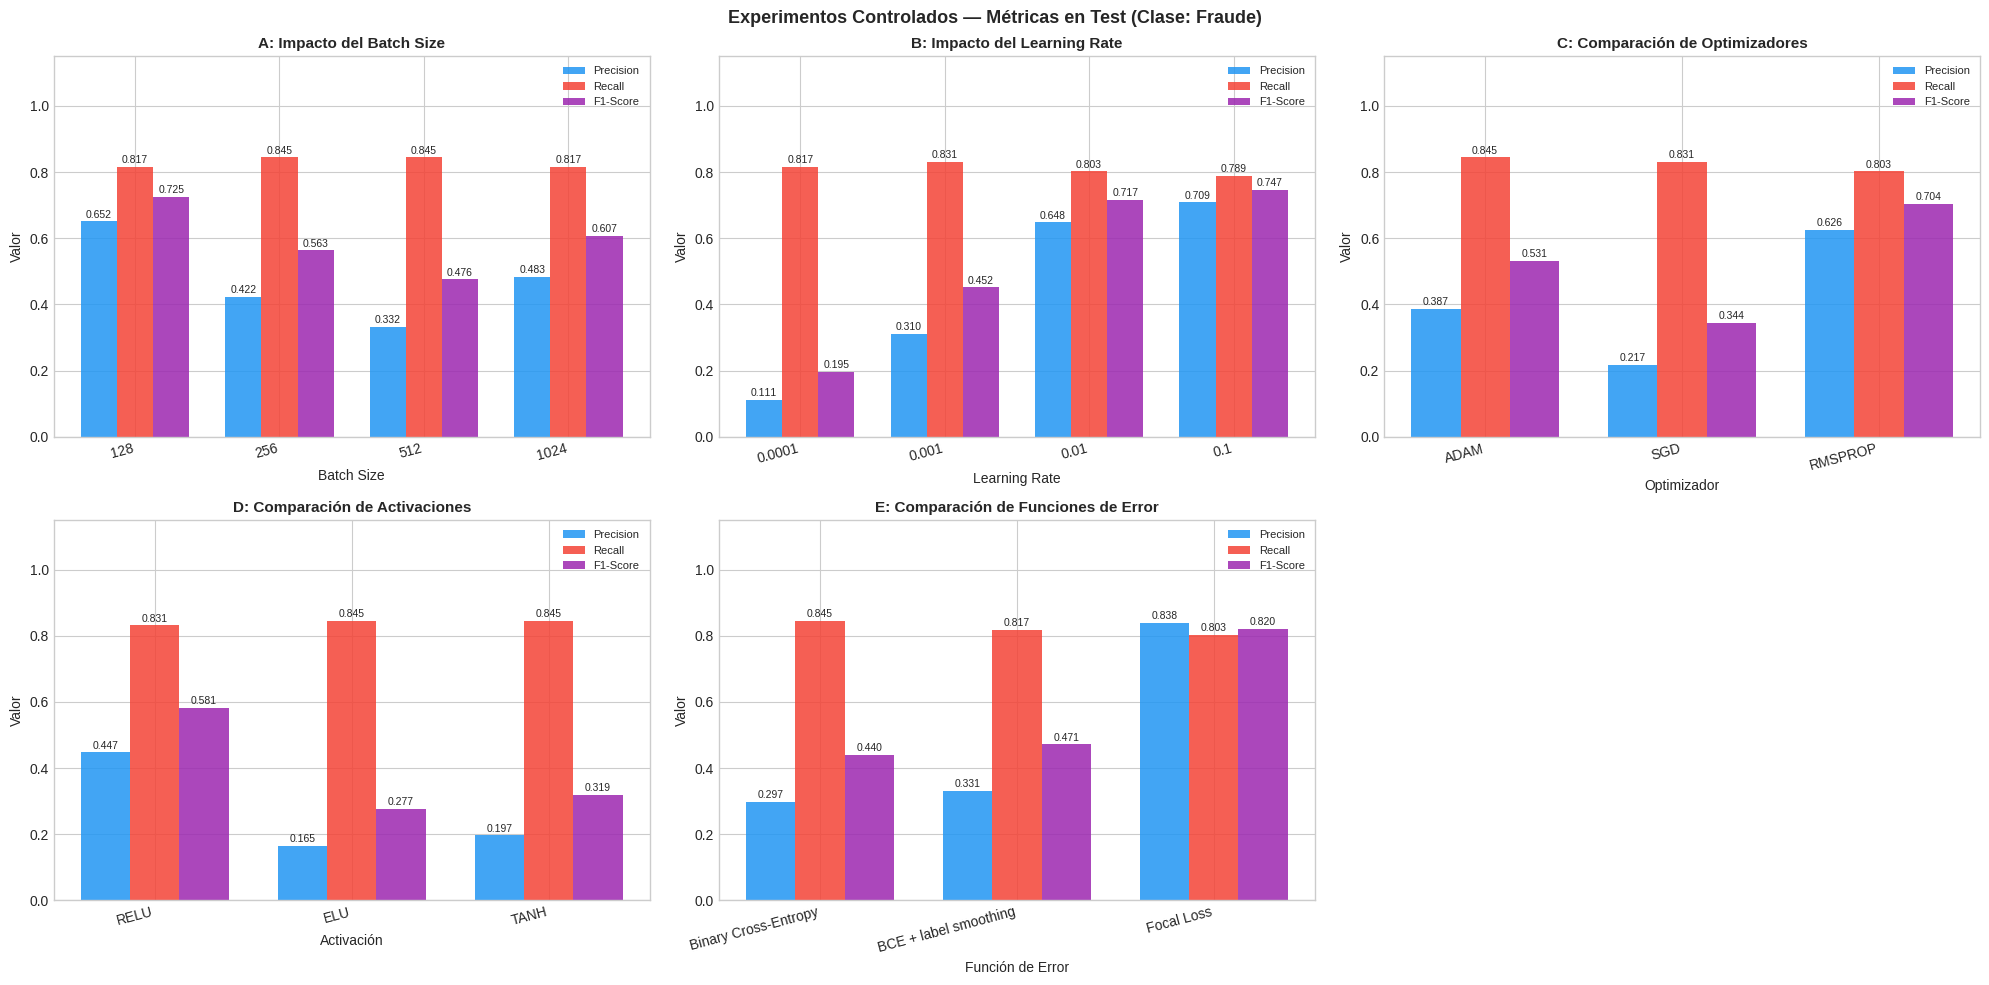

Análisis automático de resultados:
  A) Batch Size: mejor F1 → 128.0 (F1=0.7250); mejor Recall → 256.0 (Recall=0.8451)
  B) Learning Rate: mejor F1 → 0.1 (F1=0.7467); mejor Recall → 0.001 (Recall=0.8310)
  C) Optimizador: mejor F1 → RMSPROP (F1=0.7037); mejor Recall → ADAM (Recall=0.8451)
  D) Activación: mejor F1 → RELU (F1=0.5813); mejor Recall → ELU (Recall=0.8451)
  E) Función de Error: mejor F1 → Focal Loss (F1=0.8201); mejor Recall → Binary Cross-Entropy (Recall=0.8451)

Interpretación:
  - F1-Score resume el equilibrio entre precision y recall.
  - Recall prioriza detectar fraudes, pero puede aumentar falsos positivos.
  - La selección final debe justificarse según el objetivo: equilibrio general o máxima detección de fraude.


In [ ]:
# Visualización comparativa de los experimentos controlados
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

def bar_comparison(ax, df, x_col, title):
    x_labels = [str(v) for v in df[x_col]]
    xpos = np.arange(len(x_labels))
    width = 0.25
    for i, (metric, color) in enumerate(zip(
            ['Precision', 'Recall', 'F1-Score'],
            [COLORS['legit'], COLORS['fraud'], '#9C27B0'])):
        bars = ax.bar(xpos + i * width, df[metric], width,
                      label=metric, color=color, alpha=0.85)
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                    f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(xpos + width)
    ax.set_xticklabels(x_labels, rotation=15, ha='right')
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(x_col)
    ax.set_ylabel('Valor')
    ax.legend(fontsize=8)

bar_comparison(axes[0], df_A, 'Batch Size',       'A: Impacto del Batch Size')
bar_comparison(axes[1], df_B, 'Learning Rate',    'B: Impacto del Learning Rate')
bar_comparison(axes[2], df_C, 'Optimizador',      'C: Comparación de Optimizadores')
bar_comparison(axes[3], df_D, 'Activación',       'D: Comparación de Activaciones')
bar_comparison(axes[4], df_E, 'Función de Error', 'E: Comparación de Funciones de Error')
axes[5].axis('off')

plt.suptitle('Experimentos Controlados — Métricas en Test (Clase: Fraude)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Análisis automático de resultados:")
for nombre, df_exp, col in [
    ('A) Batch Size', df_A, 'Batch Size'),
    ('B) Learning Rate', df_B, 'Learning Rate'),
    ('C) Optimizador', df_C, 'Optimizador'),
    ('D) Activación', df_D, 'Activación'),
    ('E) Función de Error', df_E, 'Función de Error')
]:
    best_f1 = df_exp.loc[df_exp['F1-Score'].idxmax()]
    best_recall = df_exp.loc[df_exp['Recall'].idxmax()]
    print(f"  {nombre}: mejor F1 → {best_f1[col]} (F1={best_f1['F1-Score']:.4f}); "
          f"mejor Recall → {best_recall[col]} (Recall={best_recall['Recall']:.4f})")

print("\nInterpretación:")
print("  - F1-Score resume el equilibrio entre precision y recall.")
print("  - Recall prioriza detectar fraudes, pero puede aumentar falsos positivos.")
print("  - La selección final debe justificarse según el objetivo: equilibrio general o máxima detección de fraude.")


## 9. Técnicas de Optimización y Regularización

### Comparación: Sin Optimización vs Con Optimización

Se compara un modelo simple (sin regularización) contra el modelo optimizado con:
- **Dropout** progresivo por capa
- **Batch Normalization**
- **Regularización L2**
- **ReduceLROnPlateau** como scheduler dinámico
- **class_weight** más agresivo ({0:1, 1:15})

In [ ]:
# Modelo SIN optimización (sin BN, sin Dropout, sin L2)
model_no_opt = keras.Sequential([
    keras.Input(shape=(X_train_np.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1,   activation='sigmoid')
], name='Sin_Optimizacion')

model_no_opt.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

print("Entrenando modelo SIN optimización...")
hist_no_opt = model_no_opt.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=40, batch_size=512,
    class_weight=CLASS_WEIGHT,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                              restore_best_weights=True)],
    verbose=0
)
print("Listo.")

Entrenando modelo SIN optimización...
Listo.


In [ ]:
# Modelo CON optimización completa
model_opt = build_mlp(
    input_dim=X_train_np.shape[1],
    units=[256, 128, 64, 32],
    dropout_rates=[0.5, 0.4, 0.3, 0.2],
    use_bn=True,
    l2_reg=0.001,
    learning_rate=0.001,
    optimizer_name='adam'
)

print("Entrenando modelo CON optimización completa...")
hist_opt = model_opt.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=50, batch_size=512,
    class_weight={0: 1.0, 1: 15.0},
    callbacks=[
        EarlyStopping(monitor='val_auc', patience=10,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7)
    ],
    verbose=0
)
print("Listo.")

Entrenando modelo CON optimización completa...
Listo.


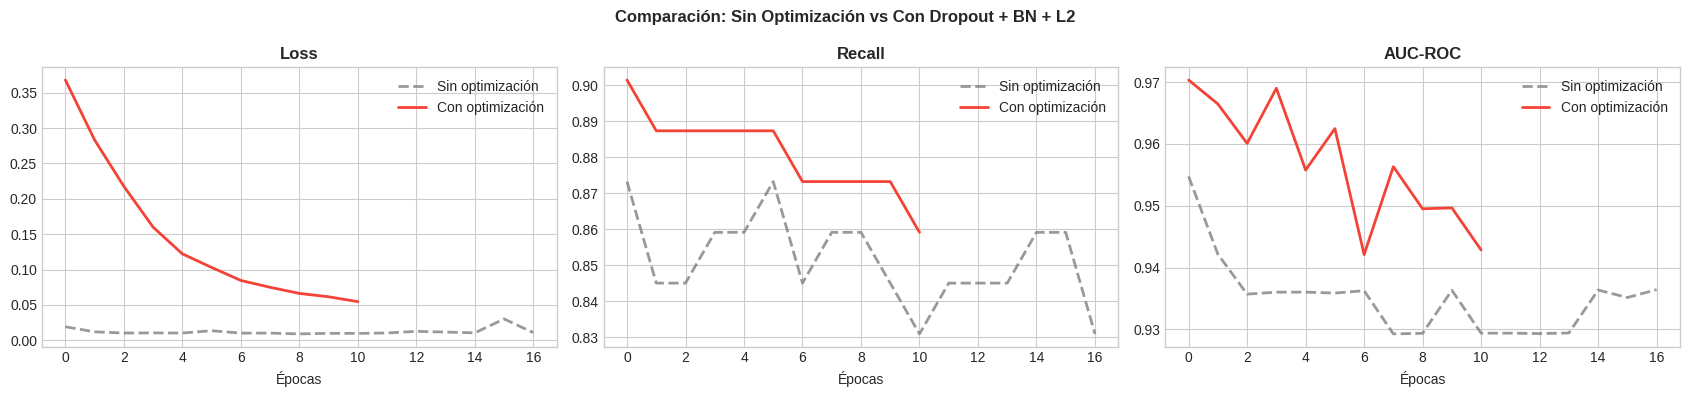


Tabla Comparativa — Impacto de la Optimización:


,Modelo,Precision,Recall,F1-Score,AUC-ROC
0,Sin Optimización,0.7500,0.8028,0.7755,0.9530
1,Modelo Base (BN + Dropout),0.8235,0.7887,0.8058,0.9133
2,Modelo Optimizado Completo,0.2390,0.8451,0.3727,0.9439


In [ ]:
# Gráfico comparativo: sin vs con optimización
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
metric_pairs = [('val_loss','Loss'), ('val_recall','Recall'), ('val_auc','AUC-ROC')]

for ax, (metric, label) in zip(axes, metric_pairs):
    ax.plot(hist_no_opt.history[metric], color='gray', lw=2,
            linestyle='--', label='Sin optimización', alpha=0.8)
    ax.plot(hist_opt.history[metric], color=COLORS['fraud'], lw=2,
            label='Con optimización')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Épocas')
    ax.legend()

plt.suptitle('Comparación: Sin Optimización vs Con Dropout + BN + L2',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_optimizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla comparativa
df_opt_compare = pd.DataFrame([
    quick_eval(model_no_opt, 'Sin Optimización'),
    quick_eval(model_base,   'Modelo Base (BN + Dropout)'),
    quick_eval(model_opt,    'Modelo Optimizado Completo')
])
print("\nTabla Comparativa — Impacto de la Optimización:")
display(df_opt_compare[['Modelo','Precision','Recall','F1-Score','AUC-ROC']])

## 10. Evaluación Final y Selección del Modelo Recomendado

En esta sección no se asume automáticamente que el modelo más regularizado es el mejor.  
Se evalúan los modelos con su **propio threshold óptimo calculado en validación** y luego se selecciona el modelo recomendado según el criterio principal:

- **F1-Score:** mejor equilibrio entre precision y recall.
- **Recall:** mayor detección de fraudes, aceptando más falsos positivos.
- **AUC-ROC:** capacidad general de separar transacciones legítimas y fraudulentas.


Threshold óptimo del modelo optimizado (max F1 en validación): 0.85

  EVALUACIÓN: Modelo Optimizado con Regularización
  Accuracy    : 0.9953
  Precision   : 0.2390
  Recall      : 0.8451
  F1-Score    : 0.3727
  AUC-ROC     : 0.9439

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     42488
      Fraude       0.24      0.85      0.37        71

    accuracy                           1.00     42559
   macro avg       0.62      0.92      0.69     42559
weighted avg       1.00      1.00      1.00     42559



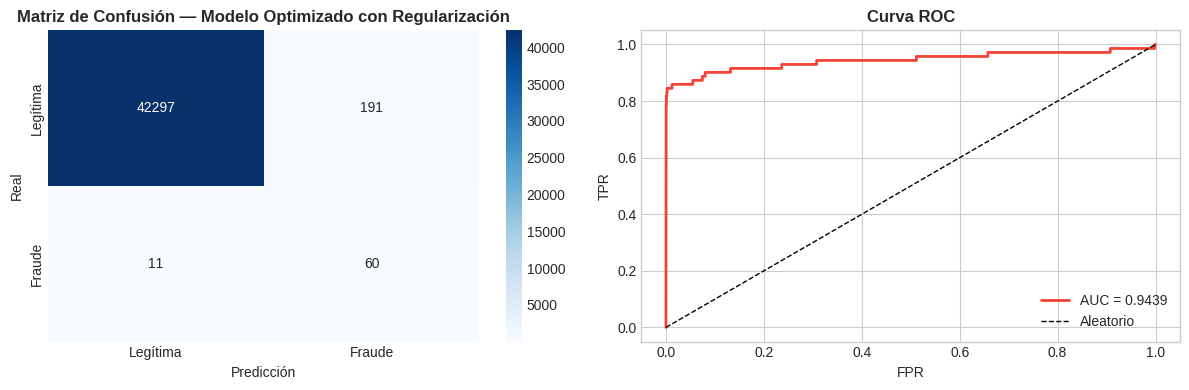

In [ ]:
# Evaluación detallada del modelo optimizado
# Se calcula su propio threshold óptimo en validación, no se reutiliza el threshold del modelo base.
y_val_prob_opt = model_opt.predict(X_val_np, verbose=0).flatten()
f1_vals_opt = [
    f1_score(y_val_np, (y_val_prob_opt >= t).astype(int), zero_division=0)
    for t in THRESHOLDS
]
best_threshold_opt = THRESHOLDS[np.argmax(f1_vals_opt)]
print(f"Threshold óptimo del modelo optimizado (max F1 en validación): {best_threshold_opt:.2f}")

metrics_final = evaluate_model(
    model_opt, X_test_np, y_test_np,
    threshold=best_threshold_opt,
    model_name='Modelo Optimizado con Regularización'
)


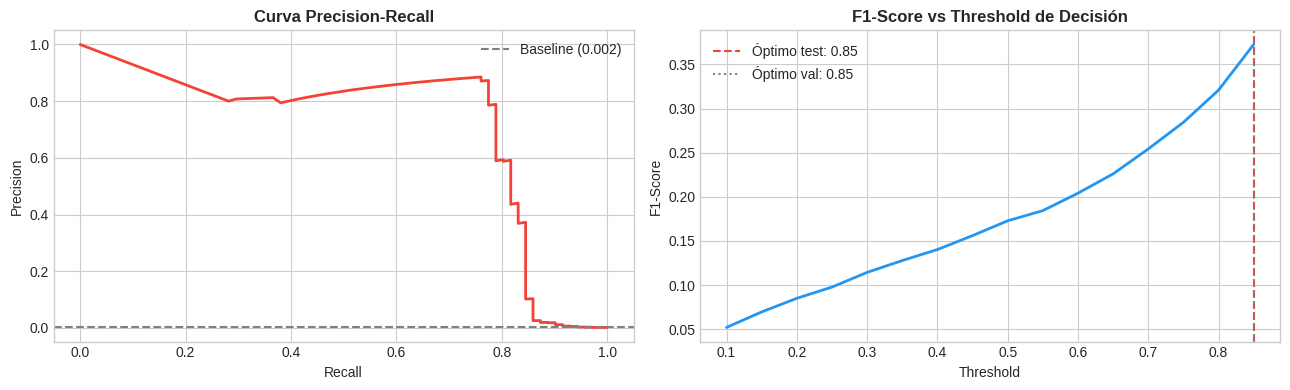

In [ ]:
# Curva Precision-Recall y F1 vs Threshold del modelo optimizado
y_prob_final = model_opt.predict(X_test_np, verbose=0).flatten()
prec_arr, rec_arr, _ = precision_recall_curve(y_test_np, y_prob_final)
f1_thr = [f1_score(y_test_np, (y_prob_final>=t).astype(int), zero_division=0)
          for t in THRESHOLDS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(rec_arr, prec_arr, color=COLORS['fraud'], lw=2)
axes[0].axhline(y_test_np.mean(), color='gray', linestyle='--',
                label=f'Baseline ({y_test_np.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend()

best_idx = np.argmax(f1_thr)
axes[1].plot(THRESHOLDS, f1_thr, color=COLORS['legit'], lw=2)
axes[1].axvline(THRESHOLDS[best_idx], color=COLORS['fraud'], linestyle='--',
                label=f'Óptimo test: {THRESHOLDS[best_idx]:.2f}')
axes[1].axvline(best_threshold_opt, color='gray', linestyle=':',
                label=f'Óptimo val: {best_threshold_opt:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Threshold de Decisión', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Tabla resumen final de todos los modelos
resumen_final = pd.DataFrame([
    quick_eval(model_no_opt, 'Sin Optimización (baseline)'),
    quick_eval(model_base,   'Modelo Base (SMOTE + BN + Dropout)'),
    quick_eval(model_opt,    'Modelo Optimizado con Regularización')
])

print("=" * 75)
print("  TABLA RESUMEN FINAL — MÉTRICAS EN CONJUNTO DE TEST")
print("=" * 75)
display(resumen_final[['Modelo','Precision','Recall','F1-Score','AUC-ROC','Threshold']].set_index('Modelo'))

mejor_f1 = resumen_final.loc[resumen_final['F1-Score'].idxmax()]
mejor_recall = resumen_final.loc[resumen_final['Recall'].idxmax()]
mejor_auc = resumen_final.loc[resumen_final['AUC-ROC'].idxmax()]

print("\nSelección según criterio:")
print(f"  Mejor equilibrio por F1-Score : {mejor_f1['Modelo']} | F1={mejor_f1['F1-Score']:.4f} | Precision={mejor_f1['Precision']:.4f} | Recall={mejor_f1['Recall']:.4f}")
print(f"  Mayor detección por Recall    : {mejor_recall['Modelo']} | Recall={mejor_recall['Recall']:.4f} | Precision={mejor_recall['Precision']:.4f}")
print(f"  Mejor separación por AUC-ROC  : {mejor_auc['Modelo']} | AUC={mejor_auc['AUC-ROC']:.4f}")

print("\nModelo recomendado para el informe:")
print(f"  Si se prioriza equilibrio general, usar: {mejor_f1['Modelo']}.")
print(f"  Si se prioriza detectar la mayor cantidad de fraudes, usar: {mejor_recall['Modelo']}, explicando el costo en falsos positivos.")


  TABLA RESUMEN FINAL — MÉTRICAS EN CONJUNTO DE TEST


,Precision,Recall,F1-Score,AUC-ROC,Threshold
Modelo,,,,,
Sin Optimización (baseline),0.7500,0.8028,0.7755,0.9530,0.85
Modelo Base (SMOTE + BN + Dropout),0.8235,0.7887,0.8058,0.9133,0.80
Modelo Optimizado con Regularización,0.2390,0.8451,0.3727,0.9439,0.85



Selección según criterio:
  Mejor equilibrio por F1-Score : Modelo Base (SMOTE + BN + Dropout) | F1=0.8058 | Precision=0.8235 | Recall=0.7887
  Mayor detección por Recall    : Modelo Optimizado con Regularización | Recall=0.8451 | Precision=0.2390
  Mejor separación por AUC-ROC  : Sin Optimización (baseline) | AUC=0.9530

Modelo recomendado para el informe:
  Si se prioriza equilibrio general, usar: Modelo Base (SMOTE + BN + Dropout).
  Si se prioriza detectar la mayor cantidad de fraudes, usar: Modelo Optimizado con Regularización, explicando el costo en falsos positivos.


## 11. Conclusiones

### Resultados Principales

1. **Desbalance extremo:** El dataset tiene menos de 0.2% de fraudes, por lo que `accuracy` no es una métrica suficiente. Un modelo que prediga siempre la clase mayoritaria puede obtener alta accuracy, pero no detectar fraudes.

2. **Preprocesamiento correcto:** `Time` y `Amount` se escalan con `StandardScaler` ajustado solo sobre entrenamiento. Esto evita data leakage y mantiene una evaluación más confiable.

3. **Métricas relevantes:** Para este caso, las métricas más importantes son `precision`, `recall`, `F1-Score` y `AUC-ROC`.  
   - `Recall` mide cuántos fraudes reales se detectan.
   - `Precision` mide cuántas alertas realmente son fraude.
   - `F1-Score` resume el equilibrio entre ambas.

4. **Experimentos controlados:** Se evaluó el impacto de batch size, learning rate, optimizador, activación y función de error/pérdida variando un parámetro a la vez. Las tablas y gráficos permiten justificar qué configuración funciona mejor según las métricas.

5. **Regularización y estabilidad:** Dropout, Batch Normalization y L2 ayudan a estabilizar el entrenamiento y reducir overfitting. Sin embargo, el modelo más regularizado no necesariamente será siempre el mejor por F1; por eso se compara explícitamente contra el baseline y el modelo base.

6. **Selección del modelo:** La elección final debe justificarse con la tabla resumen:
   - Si el objetivo es equilibrio general, se recomienda el modelo con mayor **F1-Score**.
   - Si el objetivo del negocio es detectar la mayor cantidad de fraudes posibles, se puede priorizar el modelo con mayor **Recall**, explicando que puede generar más falsos positivos.

### Posibles Mejoras

- Probar una búsqueda sistemática de hiperparámetros con Keras Tuner u Optuna.
- Evaluar distintos costos para falsos positivos y falsos negativos.
- Ajustar el threshold según el costo financiero real del fraude.
- Usar validación cruzada estratificada para estimaciones más robustas.
- Probar arquitecturas adicionales o ensambles, manteniendo la interpretabilidad de las métricas.


